In [3]:
import matplotlib.pyplot as plt
import os
import numpy as np
import plotly.graph_objects as go
# from tqdm import tqdm
from network_funcs import *
from qopt_funcs import *
import networkx as nx
# import random
import time
import shutil    # to copy files at the end of the script

In [41]:
def plot_network(cartesian_coords, rate_matrix, R, filename='earth', caption='',
                         bckgrnd_color = 'midnightblue', pt_color='yellow', edge_color='white'):    # ft chatgpt
    # could be improved, eg R must be the length of the coords vecs so its just messy to input it separately
    deg_distr = np.sum(rate_matrix > 0, axis=1)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # generate cartesian coords arrays
    x = cartesian_coords[:, 0]
    y = cartesian_coords[:, 1]
    z = cartesian_coords[:, 2]
    # represent transparent sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = R * np.outer(np.cos(u), np.sin(v))
    y_sphere = R * np.outer(np.sin(u), np.sin(v))
    z_sphere = R * np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(x_sphere, y_sphere, z_sphere, color='blue', alpha=0.2)
    # represent points
    ax.scatter(x, y, z, s=np.log(deg_distr+1)*50, color=pt_color)
    # represent paths between points as geodetic curves
    n_points = cartesian_coords.shape[0]
    for i in range(n_points):
        for j in range(i+1, n_points):
            if rate_matrix[i, j] > 0:
                phi = np.arccos(np.dot(cartesian_coords[i], cartesian_coords[j]) / (R**2))    # the angle bw the 2 vecs
                t = np.linspace(0, phi, 100)               # for the parametric curve
                x_arc = np.sin(t) * (cartesian_coords[i, 0] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 0] / np.sin(phi))
                y_arc = np.sin(t) * (cartesian_coords[i, 1] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 1] / np.sin(phi))
                z_arc = np.sin(t) * (cartesian_coords[i, 2] / np.sin(phi)) + np.sin(phi - t) * (cartesian_coords[j, 2] / np.sin(phi))
                ax.plot(x_arc, y_arc, z_arc, color=edge_color, alpha=0.7, linewidth=5./(1. - np.log(rate_matrix[i, j])))
    # require same scale for all axes
    ax.set_xlim([-R, R])
    ax.set_ylim([-R, R])
    ax.set_zlim([-R, R])
    ax.set_box_aspect([1, 1, 1])
    ax.axis('off')
    #plt.rcParams['figure.figsize'] = [15,15]
    fig.set_size_inches(8,8)
    ax.set_facecolor(bckgrnd_color)
    #plt.show()            # interactive 3d mode (not compatible w savefig)
    fig.text(.5, .15, s=caption, color=edge_color, fontsize=30)
    output_dir = 'earth_frames'
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    if not os.path.exists(output_dir + '/' + bckgrnd_color):
        os.makedirs(output_dir + '/' + bckgrnd_color)
    filename = 'earth_frames/' + bckgrnd_color + '/' + filename + '.png'
    plt.savefig(filename, dpi=300, transparent=True)
    plt.show()             # cuidado! shows a plot every fctn call
    plt.close()

    return


# entanglement rate vs $\rho$

optimal probability is 3.16781600490231e-08 for radius 106.4954492978582 with path [0, 30, 99]
optimal probability is 1.494885455814984e-07 for radius 94.91416909369084 with path [0, 30, 99]
optimal probability is 5.959029700927218e-07 for radius 84.59234224693692 with path [0, 30, 99]
optimal probability is 2.0437699851730227e-06 for radius 75.39300438651343 with path [0, 30, 99]
optimal probability is 6.130273416961654e-06 for radius 67.19408588820167 with path [0, 30, 99]


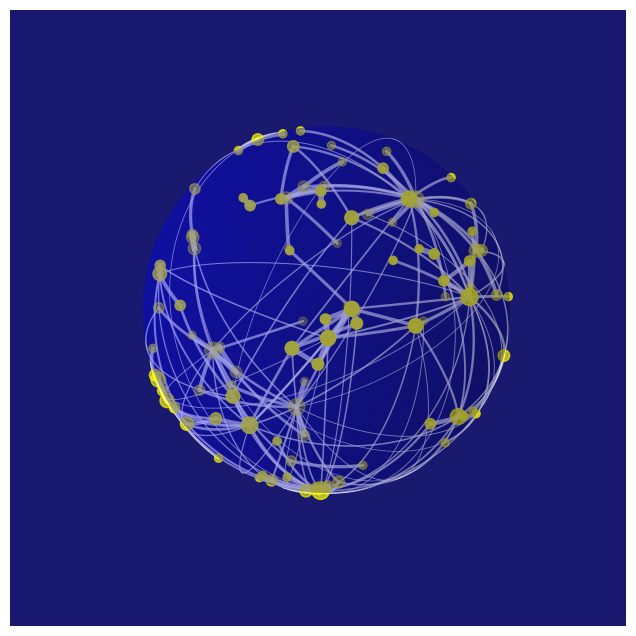

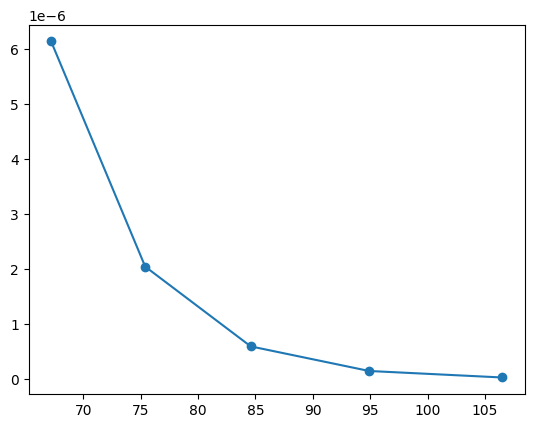

In [18]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=100

pBell = 0.5

rhos = 0.14*10**np.linspace(-2.3,-1.9,5)
radii = np.sqrt(N/4/np.pi/rhos)

# for it in range(n_iter):    # indent back below for multiple iterations
probs = []

A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
n_nodes_giant = []                                   # nr of nodes in largest (giant) component
clustering_list = []
rate_sum_accum = []
rate_sq_sum_accum = []
for radius in radii:
    alice = 0
    bob = N-1
    T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
    for i in range(N):
        for j in range(i):
            if A[i,j] == 1:
                dij = radius*Dists[i,j]
                T[i,j] = T[j,i] = transmittance_v_distance(dij)
    #plot_graph_on_sphere(coords, A_pruned, 1, filename='earth_radius%.2f' % radius)    # makes things slower
    G_pruned = nx.from_numpy_array(T)          # return a weighted graph object
    opt_prob, opt_path = optimal_quantum_repeater_path(T, pBell, alice, bob)

    print(f'optimal probability is {opt_prob} for radius {radius} with path {opt_path}')
    probs.append(opt_prob)


plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(radii, probs, marker='o')
    


# entanglement rate and shortest path length vs $p_{BSM}$

Text(0.5, 0, 'BSM success probability')

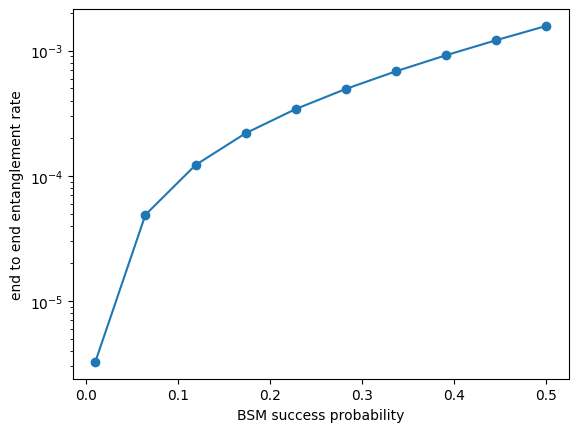

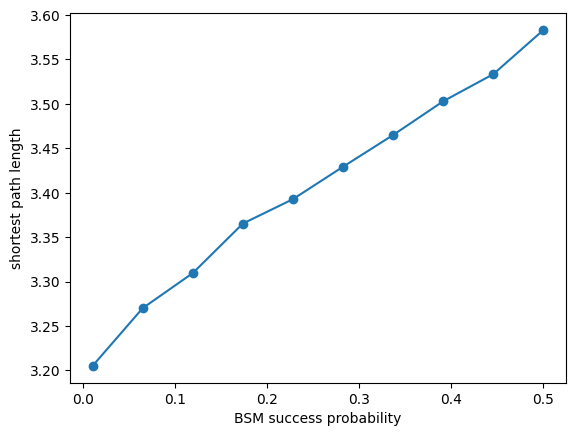

In [42]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=400
n_iter= 10                    # to accumulate statistics

p_Bells = np.linspace(0.01, .5, 10)

rhos = 10**np.linspace(-2., 1,1)
radii = np.sqrt(N/4/np.pi/rhos)

# for it in range(n_iter):    # indent back below for multiple iterations
all_probs = {pb: [] for pb in p_Bells}
all_spls = {pb: [] for pb in p_Bells}                 # average shortest path lengths

for instance in range(n_iter):
    for radius in radii:
        A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
        T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
        for i in range(N):
            for j in range(i):
                if A[i,j] == 1:
                    dij = radius*Dists[i,j]
                    T[i,j] = T[j,i] = transmittance_v_distance(dij)
        #plot_graph_on_sphere(coords, A_pruned, 1, filename='earth_radius%.2f' % radius)    # makes things slower
        # G_pruned = nx.from_numpy_array(T)          # return a weighted graph object
        for p_Bell in p_Bells:
            probs, paths = optimal_quantum_repeater_path(T, p_Bell, alice)
            
            spls = [len(path)-1 for path in paths.values()]                   # shortest path lengths

            all_probs[p_Bell].append(list(probs.values()))
            all_spls[p_Bell].append([len(path)-1 for path in paths.values()])


# plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(p_Bells, [np.average(all_probs[pb]) for pb in p_Bells], marker='o')
plt.yscale('log')
plt.ylabel('end to end entanglement rate')
plt.xlabel('BSM success probability')

plt.figure(2)
plt.plot(p_Bells, [np.average(all_spls[pb]) for pb in p_Bells], marker='o')
plt.ylabel('shortest path length')
plt.xlabel('BSM success probability')

    


In [46]:
beta = 2.6261                 # \beta param of S2 model
mu = 0.0233                   # \mu param of S2 model
N=100
n_iter= 3                    # to accumulate statistics

p_Bells = np.linspace(0.01, .5, 8)

rhos = 10**np.linspace(-2., 1,8)
radii = np.sqrt(N/4/np.pi/rhos)

# for it in range(n_iter):    # indent back below for multiple iterations

# to store results:
all_probs = {pb: [] for pb in p_Bells}
all_spls = {pb: [] for pb in p_Bells}                 # average shortest path lengths

heatmap_probs, heatmap_spls = np.zeros((len(radii), len(p_Bells))), np.zeros((len(radii), len(p_Bells)))    # to store the probabilities for the heatmap

for instance in range(n_iter):
    for r, radius in enumerate(radii):
        A, Dists, coords = S2_graph_definite_N(N, beta, mu, return_coords=True)
        T = np.zeros_like(A)                    # matrix of the graph weights ie the inverse rates (s/bit)
        for i in range(N):
            for j in range(i):
                if A[i,j] == 1:
                    dij = radius*Dists[i,j]
                    T[i,j] = T[j,i] = transmittance_v_distance(dij)
        #plot_graph_on_sphere(coords, A_pruned, 1, filename='earth_radius%.2f' % radius)    # makes things slower
        # G_pruned = nx.from_numpy_array(T)          # return a weighted graph object
        for p, p_Bell in enumerate(p_Bells):
            probs, paths = optimal_quantum_repeater_path(T, p_Bell, alice)    # ITERATE ON ALICE? use nx average_shortest_path_length fctn
            
            spls = [len(path)-1 for path in paths.values()]                   # shortest path lengths

            all_probs[p_Bell].append(list(probs.values()))
            all_spls[p_Bell].append([len(path)-1 for path in paths.values()])

        # store results in heatmaps
        heatmap_probs[r, p] += np.sum(all_probs[p_Bell])
        heatmap_spls[r, p] += np.sum(all_spls[p_Bell])
heatmap_probs /= n_iter*N
heatmap_spls /= n_iter*N


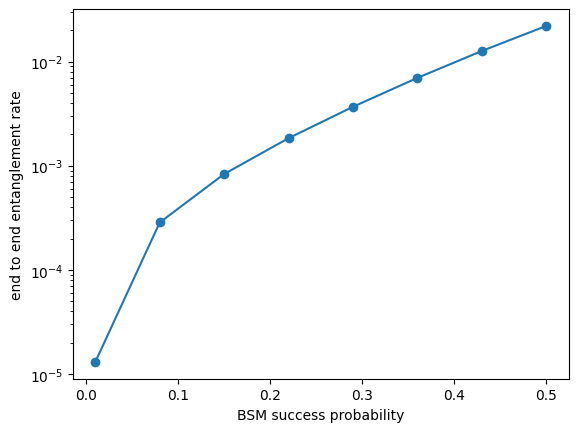

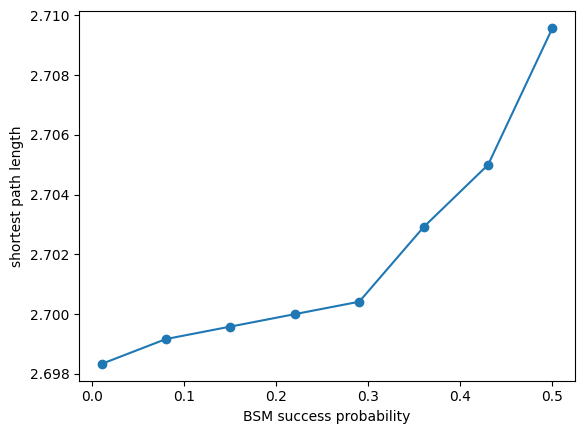

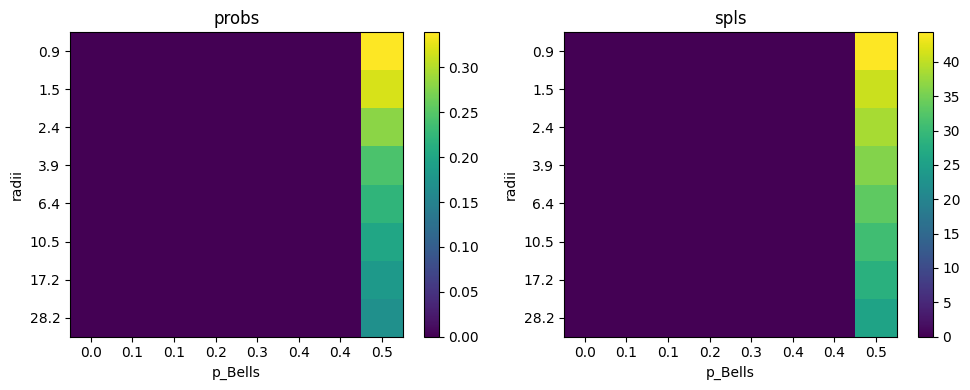

In [50]:

# plot_network(coords, T, 1, filename='earth_radius%.2f' % radius)    # drawing the last network, just for visualization

plt.plot(p_Bells, [np.average(all_probs[pb]) for pb in p_Bells], marker='o')
plt.yscale('log')
plt.ylabel('end to end entanglement rate')
plt.xlabel('BSM success probability')

plt.figure(2)
plt.plot(p_Bells, [np.average(all_spls[pb]) for pb in p_Bells], marker='o')
plt.ylabel('shortest path length')
plt.xlabel('BSM success probability')

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# format labels (1 decimal)
xticklabels = [f"{v:.1f}" for v in p_Bells]
yticklabels = [f"{v:.1f}" for v in radii]

# heatmap 1
im0 = axes[0].imshow(heatmap_probs, cmap='viridis', origin='lower', aspect='auto')
axes[0].set_title('probs')
axes[0].set_xlabel('p_Bells')
axes[0].set_ylabel('radii')
axes[0].set_xticks(range(len(p_Bells)))
axes[0].set_xticklabels(xticklabels)
axes[0].set_yticks(range(len(radii)))
axes[0].set_yticklabels(yticklabels)
plt.colorbar(im0, ax=axes[0])

# heatmap 2
im1 = axes[1].imshow(heatmap_spls, cmap='viridis', origin='lower', aspect='auto')
axes[1].set_title('spls')
axes[1].set_xlabel('p_Bells')
axes[1].set_ylabel('radii')
axes[1].set_xticks(range(len(p_Bells)))
axes[1].set_xticklabels(xticklabels)
axes[1].set_yticks(range(len(radii)))
axes[1].set_yticklabels(yticklabels)
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# print(heatmap_probs)
# print(heatmap_spls)
